In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_parquet("OC_sales_DE_pseudonymized.parquet")

Show the first rows

In [7]:
print(df.head())

     Industry    Product_Family     CHF    PC  fill_rate  Diameter max (mm)  \
0  Automotive  TF Forming Tools   25.61   9.0   0.034615               18.0   
1  Automotive  TF Forming Tools   51.84   3.0   0.014286               66.0   
2  Automotive  TF Forming Tools   55.65  19.0   0.090476               89.0   
3  Automotive  TF Forming Tools   33.53   1.0   0.050000              247.0   
4  Automotive  TF Cutting Tools  103.35   1.0   0.050000               60.0   

   Length (mm)  Width total (mm) order_date tool_type  Customer_id  coating_id  
0        101.0               0.0 2023-01-02    tool_1            1           1  
1         49.0               0.0 2023-01-02    tool_1            1           1  
2         32.0               0.0 2023-01-02    tool_2            1           2  
3         76.0               0.0 2023-01-02    tool_3            1           2  
4        276.0               0.0 2023-01-02    tool_4            1           3  


Summary Data

In [8]:
print(df.describe)

<bound method NDFrame.describe of                 Industry        Product_Family     CHF    PC  fill_rate  \
0             Automotive      TF Forming Tools   25.61   9.0   0.034615   
1             Automotive      TF Forming Tools   51.84   3.0   0.014286   
2             Automotive      TF Forming Tools   55.65  19.0   0.090476   
3             Automotive      TF Forming Tools   33.53   1.0   0.050000   
4             Automotive      TF Cutting Tools  103.35   1.0   0.050000   
...                  ...                   ...     ...   ...        ...   
855579  General Industry  TF Precision Compone   56.57   3.0        NaN   
855581  General Industry      TF Forming Tools   56.57   3.0        NaN   
855582  General Industry  TF Precision Compone   56.57   3.0        NaN   
855585        Automotive      TF Cutting Tools   56.57   3.0        NaN   
855587  General Industry      TF Cutting Tools   56.57   3.0        NaN   

        Diameter max (mm)  Length (mm)  Width total (mm) order_da

In [9]:
# Check the column names in the DataFrame
print(df.columns)

Index(['Industry', 'Product_Family', 'CHF', 'PC', 'fill_rate',
       'Diameter max (mm)', 'Length (mm)', 'Width total (mm)', 'order_date',
       'tool_type', 'Customer_id', 'coating_id'],
      dtype='object')


In [10]:
# Correct list of columns to drop based on actual column names
columns_to_drop = ["PC", "Diameter max (mm)", "Length (mm)", "Width total (mm)", "tool_type"]
df = df.drop(columns=columns_to_drop)

# Display the updated DataFrame
print(df.head())

     Industry    Product_Family     CHF  fill_rate order_date  Customer_id  \
0  Automotive  TF Forming Tools   25.61   0.034615 2023-01-02            1   
1  Automotive  TF Forming Tools   51.84   0.014286 2023-01-02            1   
2  Automotive  TF Forming Tools   55.65   0.090476 2023-01-02            1   
3  Automotive  TF Forming Tools   33.53   0.050000 2023-01-02            1   
4  Automotive  TF Cutting Tools  103.35   0.050000 2023-01-02            1   

   coating_id  
0           1  
1           1  
2           2  
3           2  
4           3  


In [11]:
print(df.describe())

                 CHF      fill_rate                     order_date  \
count  801919.000000  790500.000000                         801888   
mean      194.134926       1.266177  2024-02-03 01:32:36.015802368   
min   -589867.290000   -2051.000000            2023-01-02 00:00:00   
25%        10.360000       0.005000            2023-07-10 00:00:00   
50%        36.240000       0.016667            2024-01-31 00:00:00   
75%       120.690000       0.052778            2024-08-20 00:00:00   
max    590457.740000  269976.000000            2025-04-01 00:00:00   
std      1223.554717     429.632504                            NaN   

         Customer_id     coating_id  
count  801919.000000  801919.000000  
mean      142.147379      18.963782  
min         1.000000       1.000000  
25%        28.000000       3.000000  
50%       114.000000       9.000000  
75%       248.000000      23.000000  
max       377.000000     169.000000  
std       115.751973      24.855156  


coating ID vs...

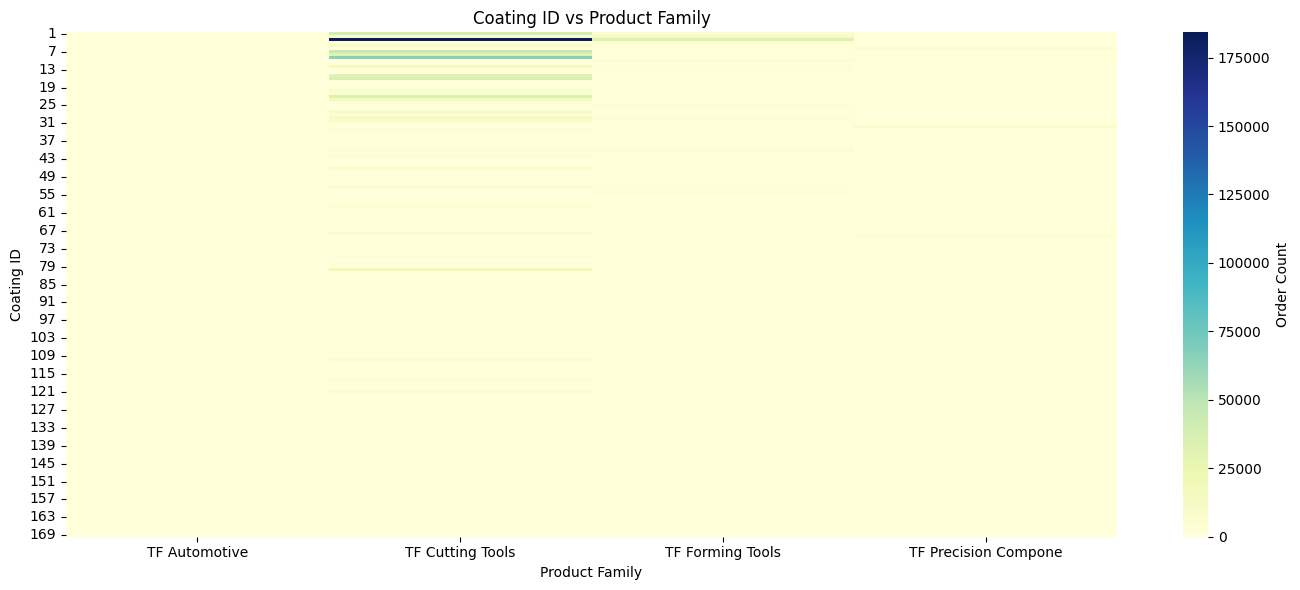

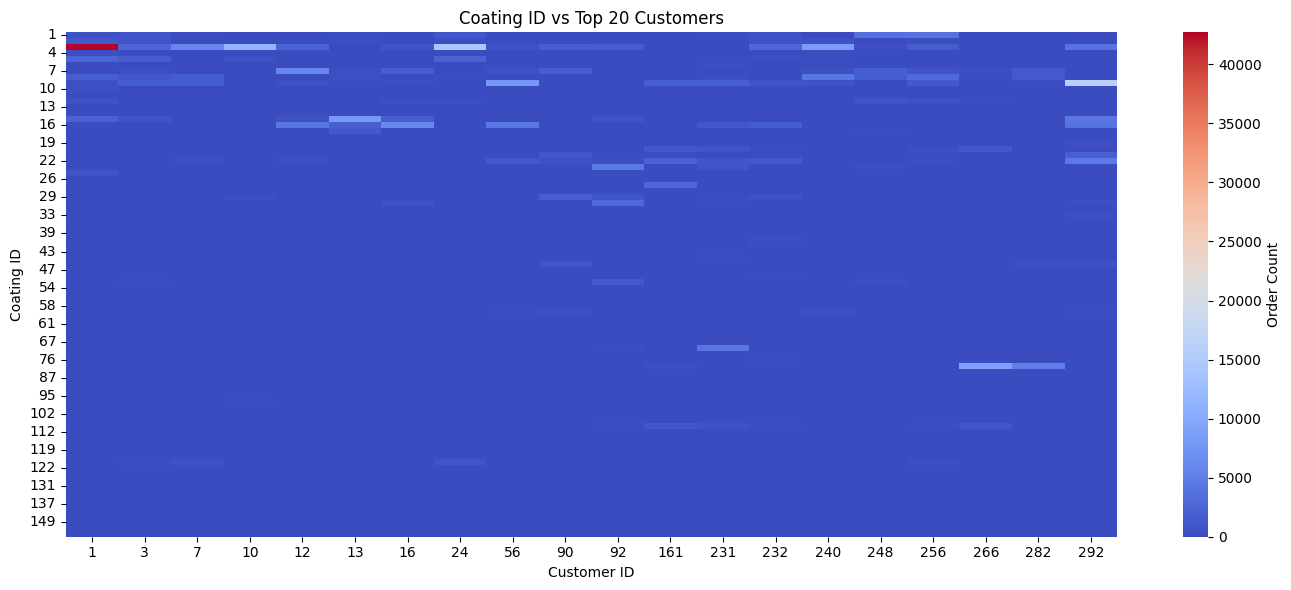

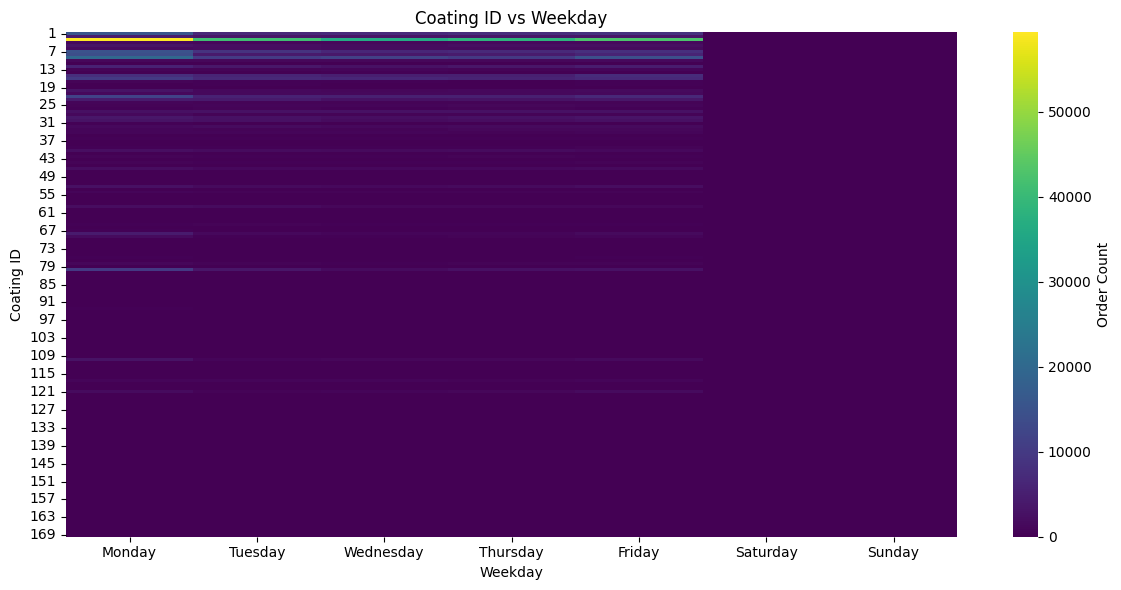

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert order_date to datetime and extract weekday
df['order_date'] = pd.to_datetime(df['order_date'])
df['weekday'] = df['order_date'].dt.day_name()

# Coating vs Product Family
coating_product = df.groupby(['coating_id', 'Product_Family']).size().unstack(fill_value=0)
plt.figure(figsize=(14, 6))
sns.heatmap(coating_product, cmap="YlGnBu", cbar_kws={'label': 'Order Count'})
plt.title('Coating ID vs Product Family')
plt.xlabel('Product Family')
plt.ylabel('Coating ID')
plt.tight_layout()
plt.show()

# Coating vs Customer ID (Top 20 customers only)
top_customers = df['Customer_id'].value_counts().nlargest(20).index
df_top = df[df['Customer_id'].isin(top_customers)]
coating_customer = df_top.groupby(['coating_id', 'Customer_id']).size().unstack(fill_value=0)
plt.figure(figsize=(14, 6))
sns.heatmap(coating_customer, cmap="coolwarm", cbar_kws={'label': 'Order Count'})
plt.title('Coating ID vs Top 20 Customers')
plt.xlabel('Customer ID')
plt.ylabel('Coating ID')
plt.tight_layout()
plt.show()

# Coating vs Weekday
coating_weekday = df.groupby(['coating_id', 'weekday']).size().unstack(fill_value=0)
# Optional: Order weekdays
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
coating_weekday = coating_weekday[weekday_order]
plt.figure(figsize=(12, 6))
sns.heatmap(coating_weekday, cmap="viridis", cbar_kws={'label': 'Order Count'})
plt.title('Coating ID vs Weekday')
plt.xlabel('Weekday')
plt.ylabel('Coating ID')
plt.tight_layout()
plt.show()


In [13]:
df.head()

,Industry,Product_Family,CHF,fill_rate,order_date,Customer_id,coating_id,weekday
0,Automotive,TF Forming Tools,25.61,0.034615,2023-01-02,1,1,Monday
1,Automotive,TF Forming Tools,51.84,0.014286,2023-01-02,1,1,Monday
2,Automotive,TF Forming Tools,55.65,0.090476,2023-01-02,1,2,Monday
3,Automotive,TF Forming Tools,33.53,0.050000,2023-01-02,1,2,Monday
4,Automotive,TF Cutting Tools,103.35,0.050000,2023-01-02,1,3,Monday


In [14]:
print(f"Number of entries in df: {len(df)}")

Number of entries in df: 801919


Data Cleaning as depicted in slide 6

In [15]:
import pandas as pd

# Drop rows with missing values for specified columns
df = df.dropna(subset=["Industry", "Product_Family", "Customer_id", "fill_rate"])

# Exclude negative values for CHF and fill_rate
df = df[(df["CHF"] >= 0) & (df["fill_rate"] >= 0)]

# Transform order_date to datetime format
df["order_date"] = pd.to_datetime(df["order_date"])

# Keep only the top 95% most frequent coating IDs
top_coating_ids = df["coating_id"].value_counts(normalize=True).loc[lambda x: x.cumsum() <= 0.95].index
df = df[df["coating_id"].isin(top_coating_ids)]

print(df.head())

     Industry    Product_Family     CHF  fill_rate order_date  Customer_id  \
0  Automotive  TF Forming Tools   25.61   0.034615 2023-01-02            1   
1  Automotive  TF Forming Tools   51.84   0.014286 2023-01-02            1   
2  Automotive  TF Forming Tools   55.65   0.090476 2023-01-02            1   
3  Automotive  TF Forming Tools   33.53   0.050000 2023-01-02            1   
4  Automotive  TF Cutting Tools  103.35   0.050000 2023-01-02            1   

   coating_id weekday  
0           1  Monday  
1           1  Monday  
2           2  Monday  
3           2  Monday  
4           3  Monday  


In [16]:
# Display the data types of each variable in the dataset
print(df.dtypes)

Industry                  object
Product_Family            object
CHF                      float64
fill_rate                float64
order_date        datetime64[ns]
Customer_id                int64
coating_id                 int64
weekday                   object
dtype: object


In [17]:
print(f"Number of entries in df: {len(df)}")

Number of entries in df: 744813


Change to coating ID to categorical variables

In [18]:
# Convert variables to categorical type where appropriate
df["coating_id"] = df["coating_id"].astype("category")
df["Customer_id"] = df["Customer_id"].astype("category")
df["Industry"] = df["Industry"].astype("category")
df["Product_Family"] = df["Product_Family"].astype("category")
df["weekday"] = df["weekday"].astype("category")

# Display updated data types
print(df.dtypes)

Industry                category
Product_Family          category
CHF                      float64
fill_rate                float64
order_date        datetime64[ns]
Customer_id             category
coating_id              category
weekday                 category
dtype: object


In [19]:

df.to_parquet("cleaned_data.parquet", index=False)  # Save as Parquet


Leos Arima Model

In [20]:
# calculate daily sum of fill_rate per coating_id
daily = df.groupby(['order_date', 'coating_id'])['fill_rate'].sum().reset_index()

#print daily
print(daily)
coating_ids = daily['coating_id'].unique()
forecast_results = []
evaluation_results = []
test_days = 7

import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error

for cid in coating_ids:
    # 2. Zeitreihe erstellen
    ts = daily[daily['coating_id'] == cid].set_index('order_date')
    ts = ts.asfreq('D')  # Lücken auffüllen


    ts['fill_rate'] = pd.to_numeric(ts['fill_rate'], errors='coerce')
    ts['fill_rate'] = ts['fill_rate'].fillna(0)

    if len(ts) <= test_days + 2:
        print(f"Not enough data for coating ID {cid}")
        continue

    # Train/Test-Split
    train = ts.iloc[:-test_days]
    test = ts.iloc[-test_days:]
    # 3. Modell fitten
    model_auto = auto_arima(ts['fill_rate'],
                            seasonal=True,
                            m=7,
                            stepwise=True,
                            suppress_warnings=True,
                            error_action="ignore",
                            trace=True)

    # 4. Prognose für 30 Tage
    forecast = model_auto.predict(n_periods=test_days)

    # Speichern der Prognose in DataFrame

    forecast_df = pd.DataFrame({
        'order_date': test.index,
        'coating_id': cid,
        'forecast_fill_rate': forecast,
        'actual_fill_rate': test['fill_rate'].values
    })
    forecast_results.append(forecast_df)

    # Fehlermetriken berechnen
    mae = mean_absolute_error(test['fill_rate'], forecast)
    #rmse = np.sqrt(mse)
    evaluation_results.append({
        'coating_id': cid,
        'MAE': mae
        #'RMSE': rmse
    })

all_forecasts = pd.concat(forecast_results, ignore_index=True)
evaluation_df = pd.DataFrame(evaluation_results)

      order_date coating_id   fill_rate
0     2023-01-02          1    0.610664
1     2023-01-02          2    0.460979
2     2023-01-02          3  110.434116
3     2023-01-02          4   12.186346
4     2023-01-02          5    1.033323
...          ...        ...         ...
20011 2025-04-01         69    0.000000
20012 2025-04-01         80    0.000000
20013 2025-04-01        110    0.000000
20014 2025-04-01        117    0.000000
20015 2025-04-01        121    0.000000

[20016 rows x 3 columns]


/var/folders/p_/7ffkm5mn1x3662hjwpjkb6fw0000gn/T/ipykernel_1141/1319005533.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily = df.groupby(['order_date', 'coating_id'])['fill_rate'].sum().reset_index()


ModuleNotFoundError: No module named 'pmdarima'

In [ ]:
avg_mae = evaluation_df['MAE'].mean()

# Durchschnittlicher RMSE
#avg_rmse = evaluation_df['RMSE'].mean()

# Ausgabe
print(f"\n Durchschnittlicher MAE über alle Coating-IDs: {avg_mae:.2f}")
import matplotlib.pyplot as plt
plt.style.use('default')
for forecast_df in forecast_results:
    cid = forecast_df['coating_id'].iloc[0]

    # Train & Test wiederherstellen
    ts = daily[daily['coating_id'] == cid].set_index('order_date')
    ts = ts.asfreq('D')  # nur Index-Auffüllen
    ts['fill_rate'] = pd.to_numeric(ts['fill_rate'], errors='coerce')  # sicherer Typ
    ts['fill_rate'] = ts['fill_rate'].fillna(0)  # fehlende Werte in dieser Spalte setzen
    test_start = forecast_df['order_date'].min()
    train = ts[ts.index < test_start]
    test = ts[ts.index >= test_start]

    # Plot
    plt.figure(figsize=(12, 5))
    train_last_60 = train.last('60D')  # oder: train[-60:] für exakt 60 Einträge
    plt.plot(train_last_60.index, pd.to_numeric(train_last_60['fill_rate'], errors='coerce'),
         label='Train (last 60 days)', color='blue')
    plt.plot(test.index, test['fill_rate'], label='Test (actual)', color='black')
    plt.plot(forecast_df['order_date'], forecast_df['forecast_fill_rate'], label='Prediction', linestyle='--', color='orange')

    plt.title(f'Prediction with Train/Test-Split – Coating ID {cid}')
    plt.xlabel('Date')
    plt.ylabel('Fill Rate')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()